<a href="https://colab.research.google.com/github/kurotiyamitali-dotcom/Python-basic-project/blob/main/task28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(
    filename,
    sep=';',
    names=['text', 'emotions']
)

print(df.head(10))
print(df.shape)
print(df.isnull().sum())

Saving train.txt to train (2).txt
                                                text  emotions
0                            i didnt feel humiliated   sadness
1  i can go from feeling so hopeless to so damned...   sadness
2   im grabbing a minute to post i feel greedy wrong     anger
3  i am ever feeling nostalgic about the fireplac...      love
4                               i am feeling grouchy     anger
5  ive been feeling a little burdened lately wasn...   sadness
6  ive been taking or milligrams or times recomme...  surprise
7  i feel as confused about life as a teenager or...      fear
8  i have been with petronas for years i feel tha...       joy
9                                i feel romantic too      love
(16000, 2)
text        0
emotions    0
dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

print(df['emotions'].unique())

le = LabelEncoder()
df['encoded_emotions'] = le.fit_transform(df['emotions'])

emotion_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

print(emotion_mapping)
print(df.head())

['sadness' 'anger' 'love' 'surprise' 'fear' 'joy']
{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}
                                                text emotions  \
0                            i didnt feel humiliated  sadness   
1  i can go from feeling so hopeless to so damned...  sadness   
2   im grabbing a minute to post i feel greedy wrong    anger   
3  i am ever feeling nostalgic about the fireplac...     love   
4                               i am feeling grouchy    anger   

   encoded_emotions  
0                 4  
1                 4  
2                 0  
3                 3  
4                 0  


In [ ]:
print("Before Lowercasing:")
print(df['text'].head(5))

df['text'] = df['text'].str.lower()

print("After Lowercasing:")
print(df['text'].head(5))

Before Lowercasing:
0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text, dtype: object
After Lowercasing:
0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text, dtype: object


In [ ]:
import string

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

before = df['text'].head(5)

df['text'] = df['text'].apply(remove_punctuation)

print("Before:")
print(before)

print("After:")
print(df['text'].head(5))

Before:
0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text, dtype: object
After:
0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text, dtype: object


In [ ]:
import re

def remove_numbers(text):
    return re.sub(r'\d+', '', text)

before = df['text'].head(5)

df['text'] = df['text'].apply(remove_numbers)

print("Before:")
print(before)

print("After:")
print(df['text'].head(5))

Before:
0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text, dtype: object
After:
0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text, dtype: object


In [ ]:
def remove_special_characters(text):
    return text.encode('ascii', 'ignore').decode('ascii')

df['text'] = df['text'].apply(remove_special_characters)

print(df['text'].head())

0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text, dtype: object


In [ ]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    return ' '.join(word for word in words if word not in stop_words)

df['text'] = df['text'].apply(remove_stopwords)

print(df['text'].head(5))

0                                didnt feel humiliated
1    go feeling hopeless damned hopeful around some...
2            im grabbing minute post feel greedy wrong
3    ever feeling nostalgic fireplace know still pr...
4                                      feeling grouchy
Name: text, dtype: object


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
import re
import string
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = text.encode('ascii', 'ignore').decode('ascii')

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return ' '.join(words)

df['cleaned_text'] = df['text'].apply(clean_text)

print(df[['text', 'cleaned_text']].head(10))

                                                text  \
0                              didnt feel humiliated   
1  go feeling hopeless damned hopeful around some...   
2          im grabbing minute post feel greedy wrong   
3  ever feeling nostalgic fireplace know still pr...   
4                                    feeling grouchy   
5      ive feeling little burdened lately wasnt sure   
6  ive taking milligrams times recommended amount...   
7     feel confused life teenager jaded year old man   
8  petronas years feel petronas performed well ma...   
9                                      feel romantic   

                                        cleaned_text  
0                              didnt feel humiliated  
1  go feeling hopeless damned hopeful around some...  
2          im grabbing minute post feel greedy wrong  
3  ever feeling nostalgic fireplace know still pr...  
4                                    feeling grouchy  
5      ive feeling little burdened lately wasnt sure 

Average: 9.3530625
Minimum: 1
Maximum: 35


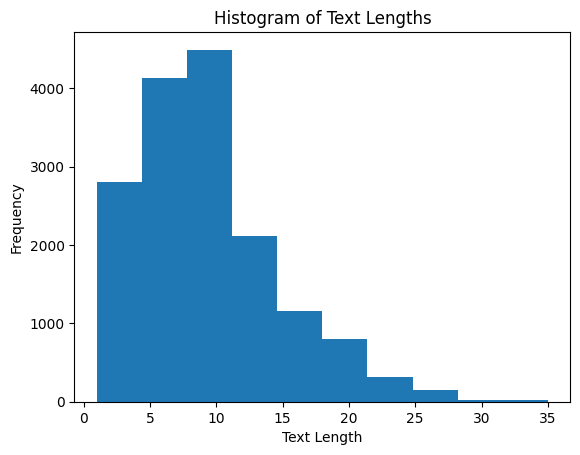

In [ ]:
import matplotlib.pyplot as plt

df['text_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))

print("Average:", df['text_length'].mean())
print("Minimum:", df['text_length'].min())
print("Maximum:", df['text_length'].max())

plt.hist(df['text_length'])
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.title('Histogram of Text Lengths')
plt.show()

In [ ]:
from google.colab import files
import pandas as pd
import re
import string
import nltk

from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(
    filename,
    sep=';',
    names=['text', 'emotions']
)

le = LabelEncoder()

df['encoded_emotions'] = le.fit_transform(
    df['emotions']
)

nltk.download('stopwords')

stop_words = set(
    stopwords.words('english')
)

def clean_text(text):
    text = text.lower()

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    text = re.sub(r'\d+', '', text)

    text = text.encode(
        'ascii', 'ignore'
    ).decode('ascii')

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

df['cleaned_text'] = df['text'].apply(
    clean_text
)

df.to_csv(
    '/content/cleaned_emotions.csv',
    index=False
)

print(df['emotions'].value_counts())

Saving train.txt to train (3).txt


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


emotions
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64
